In [1]:
# with the feedback added 
import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os
from torchdiffeq import odeint

/home/shobs/anaconda3/envs/neuro/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
# functions 
def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

def simulate_coupled_oscillators(T=4, dt=1/100, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total_oscillators = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total_oscillators)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            start_i, end_i = i * osc_per_region, (i + 1) * osc_per_region
            start_j, end_j = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[start_i:end_i, start_j:end_j] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[start_i:end_i, start_j:end_j] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

def train_heart_model(ecg_signal, device, time_sec):

    model = HeartModel().to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=500
    )

    criterion = nn.MSELoss()

    sim_input = torch.tensor(
        simulate_coupled_oscillators(T=time_sec),
        dtype=torch.float32
    ).to(device)

    target = torch.tensor(
        ecg_signal[::10],
        dtype=torch.float32
    ).unsqueeze(1).to(device)

    losses = []

    for epoch in range(15000):

        pred = model(sim_input)
        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch+1) % 2500 == 0:
            print(epoch+1, loss.item())

    return model, losses



def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training ---")
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 3
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    alpha_full = np.random.uniform(0.1, 0.7, 68 * osc_per_region)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.clip(np.concatenate([alpha_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices]), 0.05, 0.5)
    r0 = 0.1 * np.ones(N)

    phi0 = np.zeros(N)
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T
    D_full_train = D_function(t)
    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.05,
        eta_alpha=0.005,
        eta_theta=0.05,
        D_full=D_full_train,
        N=N,
        Sc=Sc_reduced_osc,
        device=device
    )

    criterion = CorrelationLoss()
    D_true = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    losses = []

    for epoch in range(40):
        with torch.no_grad():
            # use_adjoint=True is fine here since we don't need gradients
            r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, theta0, omega0, alpha0, t, use_adjoint=True)
            P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
            loss = criterion(P_out, D_true)
            losses.append(loss.item())

            theta0, omega0 = theta[-1].cpu().numpy(), omega[-1].cpu().numpy()
            alpha0 = alpha[-1].cpu().numpy()

        if (epoch + 1) % 10 == 0:
            print(f"Brain Epoch {epoch+1}/30, Loss: {loss.item():.6f}")


    final_params = {
        'r': 0.1 * np.ones(N),
        'phi': np.zeros(N),
        'theta': theta[-1].cpu().numpy(),
        'omega': omega[-1].cpu().numpy(),
        'alpha': alpha[-1].cpu().numpy()
    }
    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(
        trained_heart_model,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t,
        device,t_sec):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=18,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=5e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=10,
        threshold=1e-3,
        cooldown=5,
        min_lr=1e-5
    )

    criterion = CorrelationLoss()

    with torch.no_grad():
        sim_input = torch.tensor(
            simulate_coupled_oscillators(T=t_sec, dt=0.1),
            dtype=torch.float32
        ).to(device)
        hidden_repr = trained_heart_model.get_features(sim_input)  # (T_steps, feature_dim)

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []
    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_full=D_full_train,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        device=device
    )

    for epoch in range(40):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  
        brain_drive_full = (raw_drive)
        model.ode_func.brain_drive_full = brain_drive_full

        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            initial_brain_params['theta'],
            initial_brain_params['omega'],
            initial_brain_params['alpha'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        settle = int(0.1 * model.ode_func.fs)   # ignore first 300 ms
        loss = (
            criterion(P_out[settle:], D_true[settle:])

        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch+1}, "
                f"Loss: {loss.item():.6f}, "
                f"LR: {current_lr:.3e}"
            )


    return ecg_to_osc_mlp, losses



In [3]:
# classes 
class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU()
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)
    
    def get_features(self, x):
        return self.feature_extractor(x)
    
class BrainToHeartMLP(nn.Module):
    """
    Brain oscillators → MLP → OscillatorLayer → heart drive
    """
    def __init__(self, brain_dim, N_heart_osc, hidden_dim=64, device="cuda"):
        super().__init__()

        self.pre_osc = nn.Sequential(
            nn.Linear(brain_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, N_heart_osc)
        )

        self.osc_layer = OscillatorLayer(
            N_osc=N_heart_osc,T=10,
            device=device,
            coupling_sparsity=0.3,
            seed=123
        )

        self.post_osc = nn.Sequential(
            nn.Linear(N_heart_osc, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)  # scalar heart drive
        )

    def forward(self, brain_state):
        x = self.pre_osc(brain_state)
        osc_hidden = self.osc_layer(x)
        heart_drive = self.post_osc(osc_hidden)
        return heart_drive
    
class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta, device="cpu"):
        super().__init__()
        self.N_osc = N_osc
        self.mu = mu # nn.Parameter
        self.k = k   # nn.Parameter

        self.register_buffer("omega", omega) # nn.Parameter from OscillatorLayer
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)
        self.r_min = 0.001
        self.r_max = 2.0
        self.phase_clip = 2*np.pi
        self.input_f = None

    def forward(self, t, state):
        # state is (B, N_osc * 2) -> split into (B, N_osc) for r and phi
        B = state.shape[0]
        N_osc = self.N_osc

        r = state[:, :N_osc].unsqueeze(-1)  # (B, N_osc, 1)
        phi = state[:, N_osc:].unsqueeze(-1) # (B, N_osc, 1)

        input_f = self.input_f # (B, N_osc, 1)

        omega_i = self.omega.unsqueeze(0).unsqueeze(-1) # (1, N_osc, 1)
        omega_j = self.omega.unsqueeze(0).unsqueeze(1) # (1, 1, N_osc)
        C = self.C.unsqueeze(0) # (1, N_osc, N_osc)
        theta = self.theta.unsqueeze(0) # (1, N_osc, N_osc)

        phi_i = phi # (B, N_osc, 1)
        phi_j = phi.transpose(1, 2) # (B, 1, N_osc)

        # --- Phase term ---
        phase_term = phi_j/omega_j - phi_i/omega_i + theta/(omega_i*omega_j) # (B, N_osc, N_osc)

        # Clamp large phase excursions (numerical safety)
        phase_term = torch.clamp(
            phase_term,
            -self.phase_clip,
            self.phase_clip
        )

        # --- Power amplitude (Log-Domain Safe) ---
        r_j = r.transpose(1, 2) # (B, 1, N_osc)
        r_j_clamped = torch.clamp(r_j, self.r_min, self.r_max)

        r_safe = torch.clamp(r, self.r_min, self.r_max) # (B, N_osc, 1)
        r= r_safe

        coupling_r = self.k * torch.sum(
            C * r_j * torch.cos(phase_term),
            dim=-1,
            keepdim=True
        ) # (B, N_osc, 1)



        coupling_phi = self.k * torch.sum(
            C * (r_j/r_safe) * torch.sin(phase_term),
            dim=-1,
            keepdim=True
        ) # (B, N_osc, 1)

        dr_dt = (self.mu - r**2) * r + coupling_r + input_f # (B, N_osc, 1)
        dphi_dt = self.omega.unsqueeze(0).unsqueeze(-1) + coupling_phi # (B, N_osc, 1)

        return torch.cat([
            dr_dt.squeeze(-1),
            dphi_dt.squeeze(-1)
        ], dim=-1)


class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, T=2.0, fs=100, device="cpu",
                 coupling_sparsity=0.3, seed=42):

        super().__init__()

        self.N_osc = N_osc
        self.T = T
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        # Initialize learnable parameters
        self.mu_param = nn.Parameter(torch.tensor(1.0, device=device)) # Mu can be a learnable parameter
        self.k_param = nn.Parameter(torch.tensor(0.01, device=device)) # k can be a learnable parameter
        self.omega_param = nn.Parameter(2 * torch.pi * freqs) # omega is learnable

        # C and theta are structural, so typically not learned, but passed as buffers
        mask = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)
        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.C_buffer = C_val * mask.float()

        theta_val = torch.zeros(N_osc, N_osc, device=device)
        theta_val.fill_diagonal_(0.0)
        self.theta_buffer = theta_val

        # Instantiate the ODE function
        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer,
            device=device
        )

        # Initial conditions for the ODE solver, registered as buffers
        self.register_buffer("initial_r", torch.ones(N_osc, device=device) * 0.1)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        # Stability clamps, as in original loop for final output
        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features):
        # input_features: (B, N_osc) from ECGToOscillatorMLP.pre_osc
        B = input_features.shape[0]

        # Convert input_features to (B, N_osc, 1) for consistency in ODEFuc
        self.ode_func.input_f = input_features.unsqueeze(-1)

        # Prepare initial state y0 = [r, phi] for all batches
        initial_r_batch = self.initial_r.unsqueeze(0).repeat(B, 1) # (B, N_osc)
        initial_phi_batch = self.initial_phi.unsqueeze(0).repeat(B, 1) # (B, N_osc)
        y0 = torch.cat([initial_r_batch, initial_phi_batch], dim=-1) # (B, N_osc * 2)

        # Generate time steps
        t_eval = torch.arange(0, self.T, self.dt, device=input_features.device, dtype=torch.float32)

        # Solve the ODE using odeint (not odeint_adjoint to allow gradients to flow)
        sol = odeint(
            self.ode_func,
            y0,
            t_eval,
            method="rk4" # Use the same method as TorchRevHopfNetwork
        ) # sol shape: (T_steps, B, N_osc * 2)

        # Extract final r and phi (last time step)
        r_final = sol[-1, :, :self.N_osc] # (B, N_osc)
        phi_final = sol[-1, :, self.N_osc:] # (B, N_osc)

        # Apply final amplitude clamp as in original loop
        r_final = torch.clamp(r_final, self.r_min, self.r_max)

        return torch.cat([
            r_final * torch.cos(phi_final),
            #r_final * torch.sin(phi_final)
        ], dim=-1)




class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=16, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(N_osc=N_VNS,T=10, device=device, coupling_sparsity=0.3, seed=42)
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS * 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # [batch, ecg_dim] or [ecg_dim]
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)  # (1, ecg_dim)

        ecg_features = (
            ecg_features - ecg_features.mean(dim=-1, keepdim=True)
        ) / (ecg_features.std(dim=-1, keepdim=True) + 1e-6)

        pre = self.pre_osc(ecg_features)
        osc_hidden = self.osc_layer(pre)
        combined = torch.cat([osc_hidden], dim=-1)
        brain_drive = self.post_osc(combined)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)  # (output_dim,)
        return brain_drive


class ODEFuc(nn.Module):
    def __init__(self, mu, eta_theta, eta_omega, eta_alpha,
                 D_full, N, Sc,
                 brain_drive_full=None,
                 fs=100):

        super().__init__()
        self.mu = mu
        self.eta_theta = eta_theta
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.register_buffer("theta_const", torch.tensor(theta_init, dtype=torch.float32))
        self.register_buffer("omega_const", torch.tensor(omega_init, dtype=torch.float32))
        self.register_buffer("alpha_const", torch.tensor(alpha_init, dtype=torch.float32))
        self.register_buffer(
            "D_full",
            torch.tensor(D_full, dtype=torch.float32)
        )
        self.N = N
        self.fs = fs

        self.register_buffer(
            'Sc',
            torch.tensor(Sc, dtype=torch.float32)
        )

        # brain_drive_full is stored as a plain attribute (NOT a buffer) so that
        # when using standard odeint, the full autograd graph is preserved and
        # gradients flow back through it to ecg_to_osc_mlp.
        self.brain_drive_full = brain_drive_full

    def forward(self, t, state):

        N = self.N

        r = state[:N]
        phi = state[N:2*N]

        theta = self.theta_const
        omega = self.omega_const
        alpha = self.alpha_const

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r = torch.clamp(r, 1e-1, 2.0)
        alpha = torch.clamp(alpha, -1.0, 1.0)
        r_safe = torch.clamp(r, min=1e-6)
        r = r_safe

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]), -1e2, 1e2)  # Added clamp to prevent extreme phases

        t_idx_D = torch.clamp(
            (t * self.fs).long(),
            0,
            self.D_full.shape[0] - 1
        )
        D = self.D_full[t_idx_D]

        P = torch.sum(alpha * r * torch.cos(phi))
        e = D - P

        # ----- Brain drive -----
        if self.brain_drive_full is not None:
            t_idx_drive = torch.clamp(
                (t * self.fs).long(),
                0,
                self.brain_drive_full.shape[0] - 1
            )
            ecg_input = self.brain_drive_full[t_idx_drive]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r = torch.sum(torch.abs(self.Sc) * r[None, :] * torch.cos(phase_diff), dim=1)

        drdt = (self.mu - r**2) * r \
               + coupling_r \
               + e * torch.cos(phi) \
               + ecg_input

        coupling_phi = torch.sum(torch.abs(self.Sc) * (r[None, :] / r_safe[:, None]) * torch.sin(phase_diff), dim=1)
        dphidt = omega + coupling_phi - (e / r_safe) * torch.sin(phi)

         # Adaptive dynamics (these are "
         # " by setting etas to 0 in Stage 2)
        dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
        domegadt = -self.eta_omega * e * torch.sin(phi)
        dalphadt = self.eta_alpha * e * r * torch.cos(phi)

        return torch.cat([
            drdt.flatten(),
            dphidt.flatten(),
            dthetadt.flatten(),
            domegadt.flatten(),
            dalphadt.flatten()
        ])


class TorchRevHopfNetwork:
    def __init__(self, mu, eta_omega, eta_alpha, eta_theta,
                 D_full, N, Sc,
                 brain_drive_full=None,
                 fs=100,
                 device="cuda"):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            eta_theta=eta_theta,
            eta_omega=eta_omega,
            eta_alpha=eta_alpha,
            D_full=D_full,
            N=N,
            Sc=Sc,
            brain_drive_full=brain_drive_full,
            fs=fs
        ).to(self.device)

    def solve(self, r0, phi0, theta0, omega0, alpha0, t_eval, use_adjoint=True):

        y0 = torch.tensor(
            np.concatenate([r0, phi0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(
            t_eval,
            device=self.device,
            dtype=torch.float32
        )

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )
        else:
            sol = odeint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )

        N = self.N

        r = sol[:, :N]
        phi = sol[:, N:2*N]

        theta = self.ode_func.theta_const
        omega = self.ode_func.omega_const
        alpha = self.ode_func.alpha_const

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)

        return r, phi, theta, omega, alpha, rcos_phi

class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):

        pred = pred - torch.mean(pred)
        target = target - torch.mean(target)

        numerator = torch.sum(pred * target)

        denominator = torch.sqrt(
            torch.sum(pred ** 2) * torch.sum(target ** 2) + self.eps
        )

        corr = numerator / denominator

        loss = 1 - corr
        return loss

In [4]:
file_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
raw = mne.io.read_raw_fif(file_raw, preload=True)

mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
sc_matrix = sc_data["sc"]

max_val = np.max(sc_matrix)
Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix
non_zero_indices_per_row = [
    np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])
]

fs_raw = 1000
train_sec = 10
test_sec = 5

start_idx = 2000
train_samples = train_sec * fs_raw
test_samples = test_sec * fs_raw

train_slice = slice(start_idx, start_idx + train_samples)
test_slice  = slice(start_idx + train_samples,
                    start_idx + train_samples + test_samples)

# ECG
ecg_train = -raw[322, train_slice][0][0]
ecg_test  = -raw[322, test_slice][0][0]

# EEG
eeg_train = mat['Value'][:, train_slice]
eeg_test  = mat['Value'][:, test_slice]

# ===============================
# PREPROCESS
# ===============================

ecg_train_processed = preprocess_signal(ecg_train, fs=1000, lowcut=1.5, highcut=20)
ecg_test_processed  = preprocess_signal(ecg_test,  fs=1000, lowcut=1.5, highcut=20)

eeg_train_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_train
])

eeg_test_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_test
])

target_indices = [1]
target_idx = target_indices[0]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")

# ===============================
# TIME AXES
# ===============================

fs_model = 100

t_train = np.arange(0, train_sec, 1/fs_model)
t_test  = np.arange(0, test_sec, 1/fs_model)

target_train = eeg_train_processed[target_idx, ::10]
target_test  = eeg_test_processed[target_idx, ::10]

D_train = interp1d(t_train, target_train,
                   kind='linear',
                   bounds_error=False,
                   fill_value=0.0)

D_test = interp1d(t_test, target_test,
                  kind='linear',
                  bounds_error=False,
                  fill_value=0.0)

trained_heart_model, heart_losses = train_heart_model(
    ecg_train_processed,
    device,train_sec
)

# ===============================
# STAGE 1: BRAIN PRETRAIN (TRAIN ONLY)
# ===============================


final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_train_processed,
    Sw_all,
    target_idx,
    non_zero_indices_per_row,
    t_train,
    D_train,
    device
)

# ===============================
# STAGE 2: ECG→BRAIN TRAINING (TRAIN ONLY)
# ===============================

trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model,
    final_brain_params,
    Sc_reduced_osc,
    N,
    D_train,
    t_train,
    device,train_sec
)


trained_heart_model.eval()
trained_mlp_model.eval()

with torch.no_grad():

    # Generate oscillator input for 5 seconds
    sim_input_test = torch.tensor(
        simulate_coupled_oscillators(T=test_sec, dt=1/fs_model),
        dtype=torch.float32
    ).to(device)

    hidden_test = trained_heart_model.get_features(sim_input_test)

    brain_drive_test = torch.tanh(
        trained_mlp_model(hidden_test)
    ).detach()
D_full_test = D_test(t_test)

model_test = TorchRevHopfNetwork(
    mu=1.0,
    eta_omega=0.0,
    eta_alpha=0.0,
    eta_theta=0.0,
    D_full=D_full_test,
    N=N,
    Sc=Sc_reduced_osc,
    brain_drive_full=brain_drive_test,
    fs=fs_model,
    device=device
)

with torch.no_grad():
    r_test, phi_test, theta_test, omega_test, alpha_test, rcos_phi_test = \
        model_test.solve(
            final_brain_params['r'],
            final_brain_params['phi'],
            final_brain_params['theta'],
            final_brain_params['omega'],
            final_brain_params['alpha'],
            t_test,
            use_adjoint=False
        )

P_test = torch.sum(
    alpha_test * r_test * torch.cos(phi_test),
    dim=1
).cpu().numpy()

target_test_np = D_test(t_test)

mse_test = np.mean((P_test - target_test_np)**2)
corr_test = np.corrcoef(P_test, target_test_np)[0, 1]

print("\n--- TEST RESULTS ---")
print("Test MSE:", mse_test)
print("Test Correlation:", corr_test)

Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...
--- Using device: cuda ---
2500 0.2797066867351532
5000 0.11967381089925766
7500 0.07143748551607132
10000 0.06119018793106079
12500 0.04674721881747246
15000 0.05430757999420166

--- Stage 1: Brain Pre-training ---


NameError: name 'theta_init' is not defined

In [ ]:
trained_heart_model.eval()
trained_mlp_model.eval()

fs_model = 100

# -------- ECG TRAIN --------
with torch.no_grad():
    sim_train = torch.tensor(
        simulate_coupled_oscillators(T=10, dt=1/fs_model),
        dtype=torch.float32
    ).to(device)

    ecg_pred_train = trained_heart_model(sim_train).cpu().numpy().flatten()

target_ecg_train = ecg_train_processed[::10]


# -------- ECG TEST --------
with torch.no_grad():
    sim_test = torch.tensor(
        simulate_coupled_oscillators(T=5, dt=1/fs_model),
        dtype=torch.float32
    ).to(device)

    ecg_pred_test = trained_heart_model(sim_test).cpu().numpy().flatten()

target_ecg_test = ecg_test_processed[::10]


# -------- EEG TRAIN --------
with torch.no_grad():
    hidden_train = trained_heart_model.get_features(sim_train)

    brain_drive_train = torch.tanh(
        trained_mlp_model(hidden_train)
    ).detach()

    D_full_train_eval = D_train(t_train)

    model_train = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_full=D_full_train_eval,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_train,
        fs=100,
        device=device
    )

    r_tr, phi_tr, theta_tr, omega_tr, alpha_tr, _ = model_train.solve(
        final_brain_params['r'],
        final_brain_params['phi'],
        final_brain_params['theta'],
        final_brain_params['omega'],
        final_brain_params['alpha'],
        t_train,
        use_adjoint=False
    )

    P_train = torch.sum(
        alpha_tr * r_tr * torch.cos(phi_tr),
        dim=1
    ).cpu().numpy()


# -------- EEG TEST --------
with torch.no_grad():
    hidden_test = trained_heart_model.get_features(sim_test)

    brain_drive_test = torch.tanh(
        trained_mlp_model(hidden_test)
    ).detach()

    model_test = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_full=D_test(t_test),
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_test,
        fs=fs_model,
        device=device
    )

    r_te, phi_te, theta_te, omega_te, alpha_te, _ = model_test.solve(
        final_brain_params['r'],
        final_brain_params['phi'],
        final_brain_params['theta'],
        final_brain_params['omega'],
        final_brain_params['alpha'],
        t_test,
        use_adjoint=False
    )

    P_test = torch.sum(
        alpha_te * r_te * torch.cos(phi_te),
        dim=1
    ).cpu().numpy()

def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    return mse, corr

# =====================================
# Ignore first 0.1 s
# =====================================
ignore_sec = 0.1
ignore_samples = int(ignore_sec * fs_model)

# -------------------------------------
# ECG TRAIN
# -------------------------------------
mse_ecg_train, corr_ecg_train = metrics(
    target_ecg_train[ignore_samples:],
    ecg_pred_train[ignore_samples:]
)

# -------------------------------------
# ECG TEST
# -------------------------------------
mse_ecg_test, corr_ecg_test = metrics(
    target_ecg_test[ignore_samples:],
    ecg_pred_test[ignore_samples:]
)

# -------------------------------------
# EEG TRAIN
# -------------------------------------
target_eeg_train = D_train(t_train)

mse_eeg_train, corr_eeg_train = metrics(
    target_eeg_train[ignore_samples:],
    P_train[ignore_samples:]
)

# -------------------------------------
# EEG TEST
# -------------------------------------
target_eeg_test = D_test(t_test)

mse_eeg_test, corr_eeg_test = metrics(
    target_eeg_test[ignore_samples:],
    P_test[ignore_samples:]
)

# -------------------------------------
# Print Results
# -------------------------------------
print("\n===== PERFORMANCE (First 0.1s Ignored) =====")

print("\nECG Train | MSE:", mse_ecg_train,
      "| Corr:", corr_ecg_train)

print("ECG Test  | MSE:", mse_ecg_test,
      "| Corr:", corr_ecg_test)

print("\nEEG Train | MSE:", mse_eeg_train,
      "| Corr:", corr_eeg_train)

print("EEG Test  | MSE:", mse_eeg_test,
      "| Corr:", corr_eeg_test)


===== PERFORMANCE (First 0.1s Ignored) =====

ECG Train | MSE: 0.01276745714966456 | Corr: 0.9937941259622105
ECG Test  | MSE: 2.03933223468468 | Corr: -0.05377037963322049

EEG Train | MSE: 9.476882534279376 | Corr: 0.17455692916949825
EEG Test  | MSE: 4.0257073135185335 | Corr: 0.07627479207276903


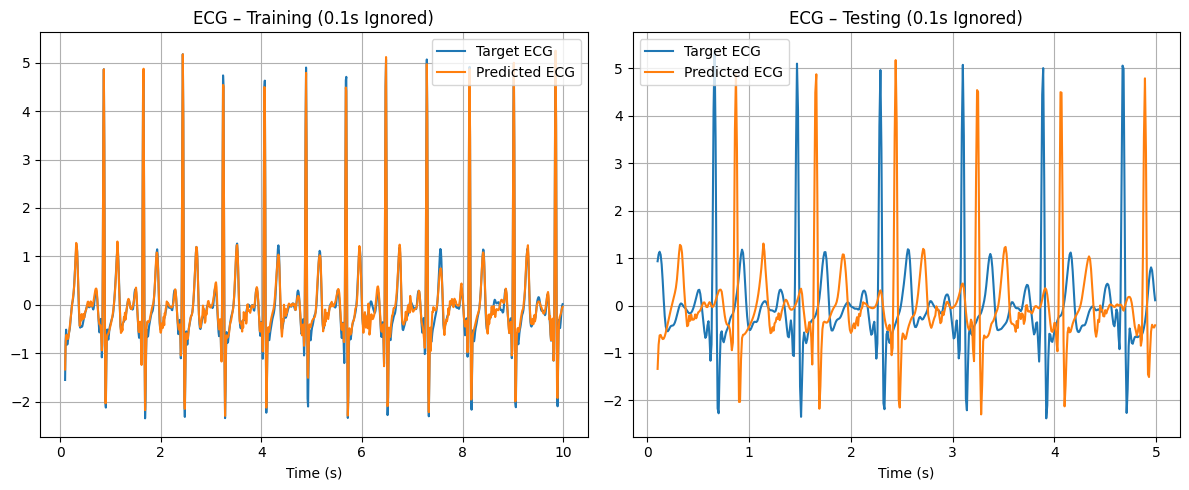

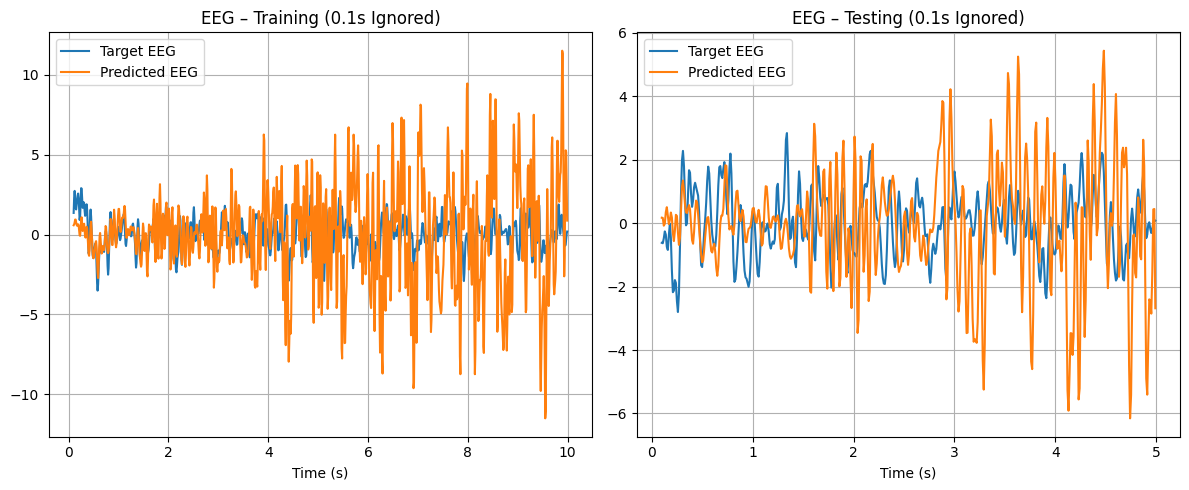

In [ ]:
ignore_sec = 0.1
ignore_samples = int(ignore_sec * fs_model)
plt.figure(figsize=(12,5))

# ---- ECG TRAIN ----
plt.subplot(1,2,1)
plt.plot(
    t_train[ignore_samples:],
    target_ecg_train[ignore_samples:],
    label="Target ECG"
)
plt.plot(
    t_train[ignore_samples:],
    ecg_pred_train[ignore_samples:],
    label="Predicted ECG"
)
plt.title("ECG – Training (0.1s Ignored)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

# ---- ECG TEST ----
plt.subplot(1,2,2)
plt.plot(
    t_test[ignore_samples:],
    target_ecg_test[ignore_samples:],
    label="Target ECG"
)
plt.plot(
    t_test[ignore_samples:],
    ecg_pred_test[ignore_samples:],
    label="Predicted ECG"
)
plt.title("ECG – Testing (0.1s Ignored)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

# ---- EEG TRAIN ----
plt.subplot(1,2,1)
plt.plot(
    t_train[ignore_samples:],
    D_train(t_train)[ignore_samples:],
    label="Target EEG"
)
plt.plot(
    t_train[ignore_samples:],
    P_train[ignore_samples:],
    label="Predicted EEG"
)
plt.title("EEG – Training (0.1s Ignored)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

# ---- EEG TEST ----
plt.subplot(1,2,2)
plt.plot(
    t_test[ignore_samples:],
    D_test(t_test)[ignore_samples:],
    label="Target EEG"
)
plt.plot(
    t_test[ignore_samples:],
    P_test[ignore_samples:],
    label="Predicted EEG"
)
plt.title("EEG – Testing (0.1s Ignored)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

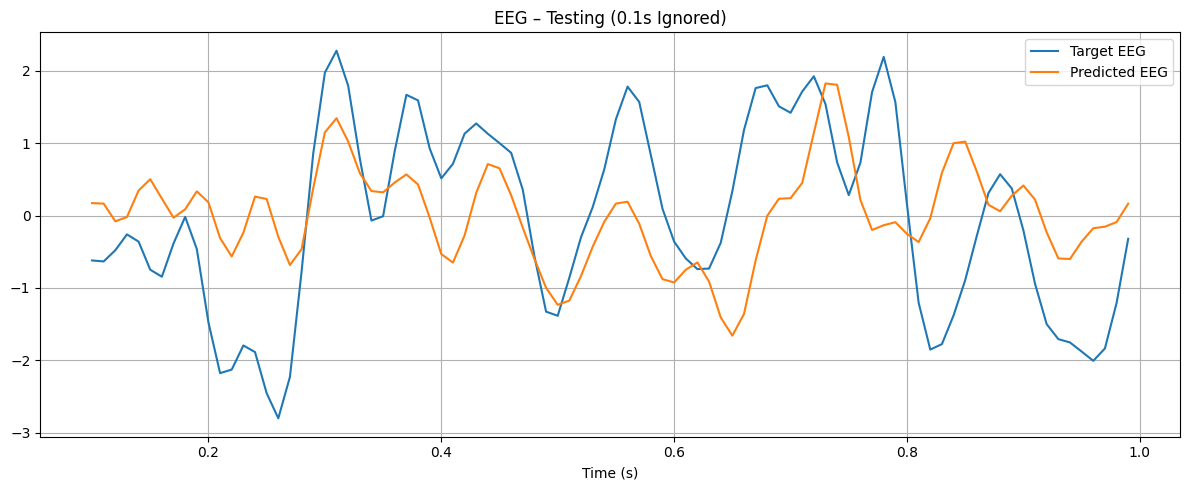

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    t_test[10:100],
    D_test(t_test)[10:100],
    label="Target EEG"
)
plt.plot(
    t_test[10:100],
    P_test[10:100],
    label="Predicted EEG"
)
plt.title("EEG – Testing (0.1s Ignored)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(metrics(target_eeg_test[10:100], P_test[10:100])[1])

0.3311849863518722
